# AgroCare Model Walkthrough

This notebook explains the end-to-end process used in AgroCare.AI: generating synthetic sensor data, training the 1D-CNN + dual-attention model, and running inference on new readings.


## Repository Map
- `utils/GenerateSynthData/generate_synthetic_dataset.py`: synthetic data generator that builds `.npz` files and analytics plots.
- `models/agrocare_net.py`: 1D CNN backbone with temporal and channel attention heads.
- `train.py`: training pipeline (splits, normalization, class weights, checkpoints, plots).
- `inference.py`: CLI utilities to load checkpoints and predict from interactive input or CSV.
- `checkpoints/` and `plots/`: saved weights and training diagnostics produced by `train.py`.


## Environment Setup
Use a Python 3.10+ environment. Create/activate a virtualenv, then install dependencies from `requirements.txt`. Small runs are light; GPU (CUDA/MPS) accelerates training but CPU works for demos.


In [ ]:
%matplotlib inline


In [ ]:
%%bash
python -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt


## Generate a Synthetic Dataset
The generator produces 60×5 sensor windows and labels using reference patterns plus augmentations. Run a small, fast generation for notebook experiments. Adjust `--total`, `--output-dir`, and `--plot-dir` as needed.


In [ ]:
%%bash
set -e
python utils/GenerateSynthData/generate_synthetic_dataset.py \
  --total 200 \
  --seed 42 \
  --no-plots \
  --output-dir data/dev \
  --plot-dir plots/dev


## Inspect the Dataset
Datasets are stored as `.npz` with arrays `X` `(N, 60, 5)` and `y` `(N,)`. Inspect shapes and class distribution before training.


In [1]:
from pathlib import Path
import numpy as np

DATA_PATH = Path("utils/GenerateSynthData/data/agrocare_dataset.npz")

if DATA_PATH.exists():
    data = np.load(DATA_PATH)
    X, y = data["X"], data["y"]
    unique, counts = np.unique(y, return_counts=True)
    dist = {int(k): int(v) for k, v in zip(unique, counts)}
    print(f'X shape: {X.shape}, y shape: {y.shape}')
    print('Class distribution:', dist)
else:
    print(f'Dataset not found at {DATA_PATH}. Run the generator cell first.')


X shape: (9999, 60, 5), y shape: (9999,)
Class distribution: {0: 3327, 1: 2633, 2: 4039}


## DataLoader and Normalization
`AgroCareDataset` (from `train.py`) applies per-channel z-score normalization and returns class weights for balanced loss.


In [25]:
from pathlib import Path
import numpy as np
from train import AgroCareDataset, CLASS_NAMES

DATA_PATH = Path("utils/GenerateSynthData/data/agrocare_dataset.npz")

if DATA_PATH.exists():
    data = np.load(DATA_PATH)
    dataset = AgroCareDataset(data["X"], data["y"], normalize=True)
    print('Channel means:', dataset.channel_means)
    print('Channel stds :', dataset.channel_stds)
    weights = dataset.get_class_weights()
    dist = dict(zip(CLASS_NAMES, weights.numpy()))
    print('Class weights:', dist)
else:
    print('Dataset missing; generate it first.')


Channel means: tensor([32.3338, 32.2188, 34.2093, 46.0233,  5.3161])
Channel stds : tensor([27.8553,  6.7780,  7.5890, 15.7218,  3.3209])
Class weights: {'Normal': np.float32(0.97172403), 'Watering Required': np.float32(1.2278488), 'Risky': np.float32(0.8004272)}


## Baseline Model: Logistic Regression
A simple, interpretable baseline that uses per-channel summary statistics (mean, std, min, max) and a Logistic Regression classifier. This serves as a lightweight reference against the deep model.


In [26]:
import numpy as np
from pprint import pprint
from models.baseline import train_logreg_baseline, build_stat_features

baseline_metrics = None

if DATA_PATH.exists():
    data = np.load(DATA_PATH)
    baseline_metrics = train_logreg_baseline(data['X'], data['y'], seed=42)
    print('Baseline Logistic Regression')
    print('Train accuracy:', round(baseline_metrics.train_accuracy, 3))
    print('Val accuracy  :', round(baseline_metrics.val_accuracy, 3))
    print('Test accuracy :', round(baseline_metrics.test_accuracy, 3))
    print('Classification report (full dataset):')
    pprint(baseline_metrics.report)
else:
    print('Dataset missing; generate it first.')


Baseline Logistic Regression
Train accuracy: 0.955
Val accuracy  : 0.959
Test accuracy : 0.959
Classification report (full dataset):
{'Normal': {'f1-score': 0.9974455296769347,
            'precision': 0.9972956730769231,
            'recall': 0.997595431319507,
            'support': 3327.0},
 'Risky': {'f1-score': 0.9448293559148062,
           'precision': 0.9805592543275633,
           'recall': 0.9116117850953206,
           'support': 4039.0},
 'Watering Required': {'f1-score': 0.9226887727518471,
                       'precision': 0.877914951989026,
                       'recall': 0.9722749715153817,
                       'support': 2633.0},
 'accuracy': 0.9561956195619562,
 'macro avg': {'f1-score': 0.9549878861145293,
               'precision': 0.9519232931311709,
               'recall': 0.9604940626434031,
               'support': 9999.0},
 'weighted avg': {'f1-score': 0.9565063090739752,
                  'precision': 0.9590990700213078,
                  'recall': 0.9

## Baseline Inference: Scenario Testing

The fitted pipeline accepts a five-channel sensor snapshot and returns a class prediction with per-class probabilities. Three representative field conditions are evaluated below — a healthy plant in stable conditions, a plant in early moisture stress, and a high-stress state requiring immediate intervention.

Each snapshot is tiled to a 60-step window, z-score normalized using training statistics, and passed through the logistic regression classifier. Sensor channels in order: soil moisture (%), soil temperature (°C), ambient temperature (°C), relative humidity (%), and UV index.

## Baseline Evaluation

Confusion matrix and one-vs-rest ROC curves for the logistic regression classifier, evaluated on all 9,999 samples. The baseline achieves strong overall accuracy but struggles most with Watering Required — a class whose defining feature (a declining soil moisture trend) is partially obscured by per-channel summary statistics.

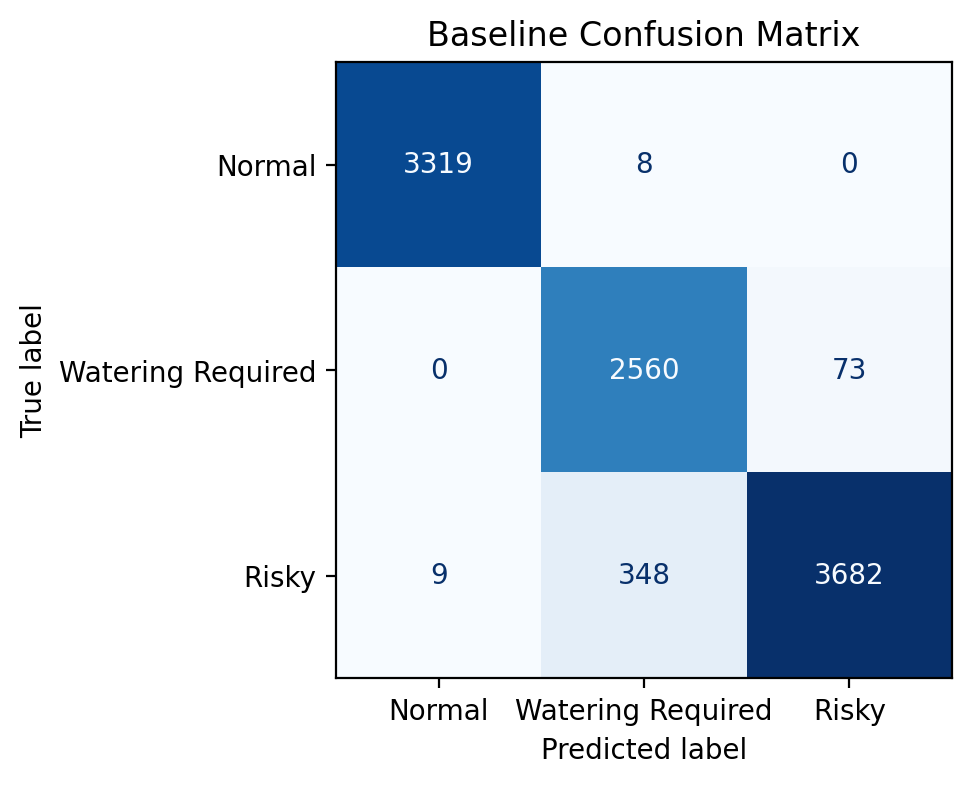

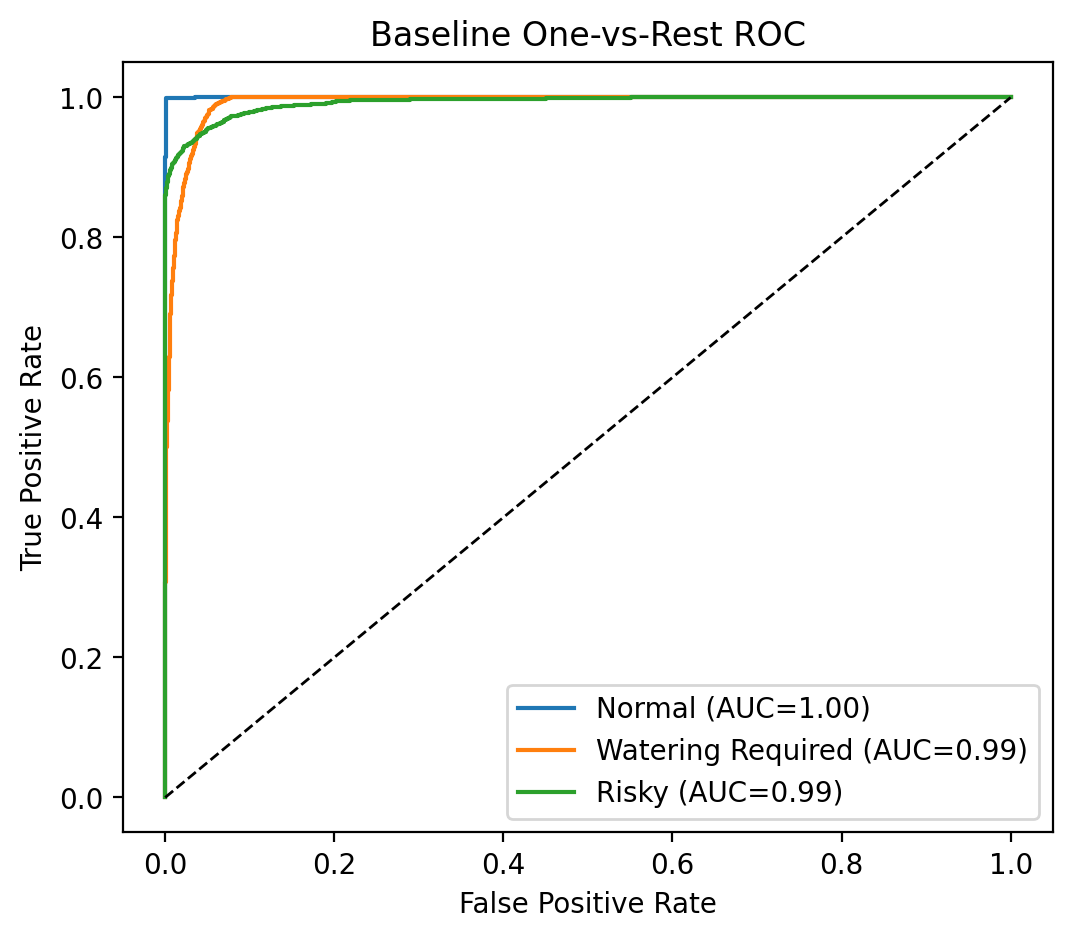

,precision,recall,f1-score,support
Normal,0.997296,0.997595,0.997446,3327.000000
Watering Required,0.877915,0.972275,0.922689,2633.000000
Risky,0.980559,0.911612,0.944829,4039.000000
accuracy,0.956196,0.956196,0.956196,0.956196
macro avg,0.951923,0.960494,0.954988,9999.000000
weighted avg,0.959099,0.956196,0.956506,9999.000000


In [27]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd
from IPython.display import Image, display
from models.baseline import build_stat_features

report_dir = Path("plots/report")
report_dir.mkdir(parents=True, exist_ok=True)

if DATA_PATH.exists() and baseline_metrics is not None:
    data = np.load(DATA_PATH)
    X_raw, y = data["X"], data["y"]
    feats, _ = build_stat_features(X_raw)
    probs = baseline_metrics.pipeline.predict_proba(feats)
    preds = probs.argmax(axis=1)

    cm = confusion_matrix(y, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Baseline Confusion Matrix")
    fig.savefig(report_dir / "baseline_confusion.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=report_dir / "baseline_confusion.png"))

    y_bin = label_binarize(y, classes=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(6, 5))
    for i, name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Baseline One-vs-Rest ROC")
    ax.legend()
    fig.savefig(report_dir / "baseline_roc.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=report_dir / "baseline_roc.png"))

    report_df = pd.DataFrame(baseline_metrics.report).T
    display(report_df)
else:
    print("Run the baseline training cell first and ensure the dataset exists.")


## AgroCareNet Evaluation

Confusion matrix and per-class classification report evaluated on the full 9,999-sample dataset using the best checkpoint (epoch 49). Probabilities are obtained via softmax over the raw logits; predictions are the argmax class.

[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]


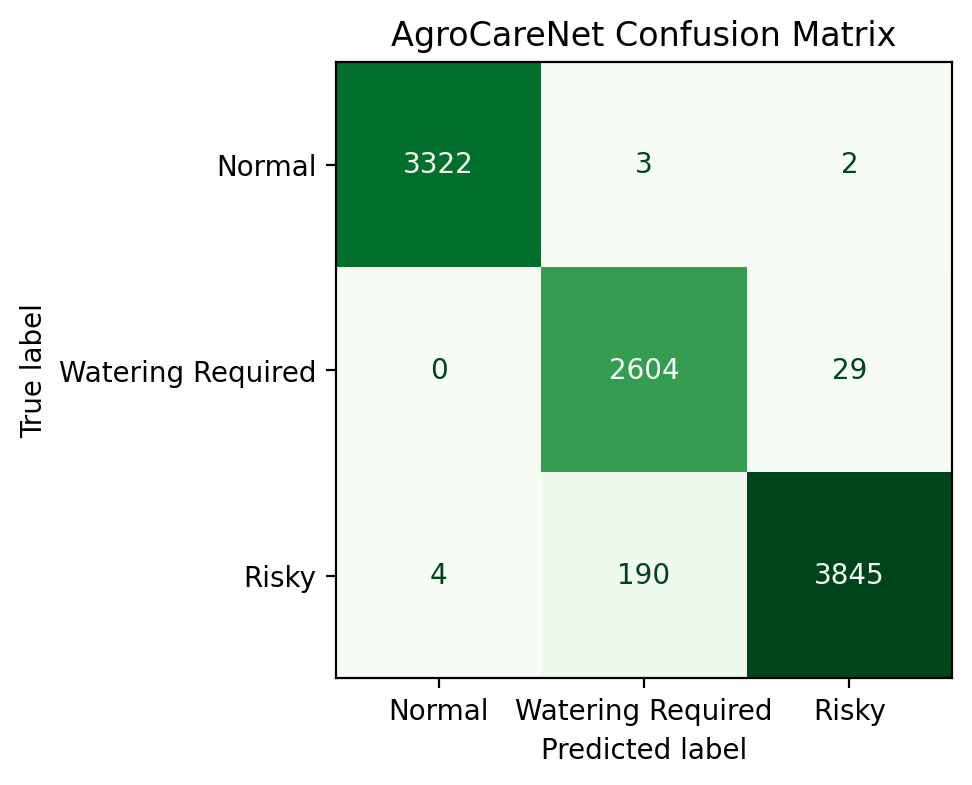

,precision,recall,f1-score,support
Normal,0.998797,0.998497,0.998647,3327.000000
Watering Required,0.930997,0.988986,0.959116,2633.000000
Risky,0.992002,0.951968,0.971573,4039.000000
accuracy,0.977198,0.977198,0.977198,0.977198
macro avg,0.973932,0.979817,0.976445,9999.000000
weighted avg,0.978199,0.977198,0.977301,9999.000000


In [28]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import Image, display
from inference import load_model

checkpoint_path = Path("checkpoints/best_model.pt")
report_dir = Path("plots/report")
report_dir.mkdir(parents=True, exist_ok=True)

if checkpoint_path.exists() and DATA_PATH.exists():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, norm_stats = load_model(str(checkpoint_path), device)
    data = np.load(DATA_PATH)
    X_raw, y = data["X"], data["y"]
    X_tensor = torch.tensor(X_raw, dtype=torch.float32, device=device)
    X_norm = (X_tensor - norm_stats["means"]) / norm_stats["stds"]
    with torch.no_grad():
        logits = model(X_norm)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
    cm = confusion_matrix(y, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title("AgroCareNet Confusion Matrix")
    fig.savefig(report_dir / "deep_confusion.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=report_dir / "deep_confusion.png"))
    report = classification_report(y, preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    display(pd.DataFrame(report).T)
else:
    print("Train the model to create checkpoints/best_model.pt and ensure DATA_PATH exists before running this cell.")


## AgroCareNet — ROC Curves

One-vs-rest ROC curves for all three classes. AUC values approaching 1.0 indicate near-perfect class separation; compare directly with the baseline ROC curves above.

[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]


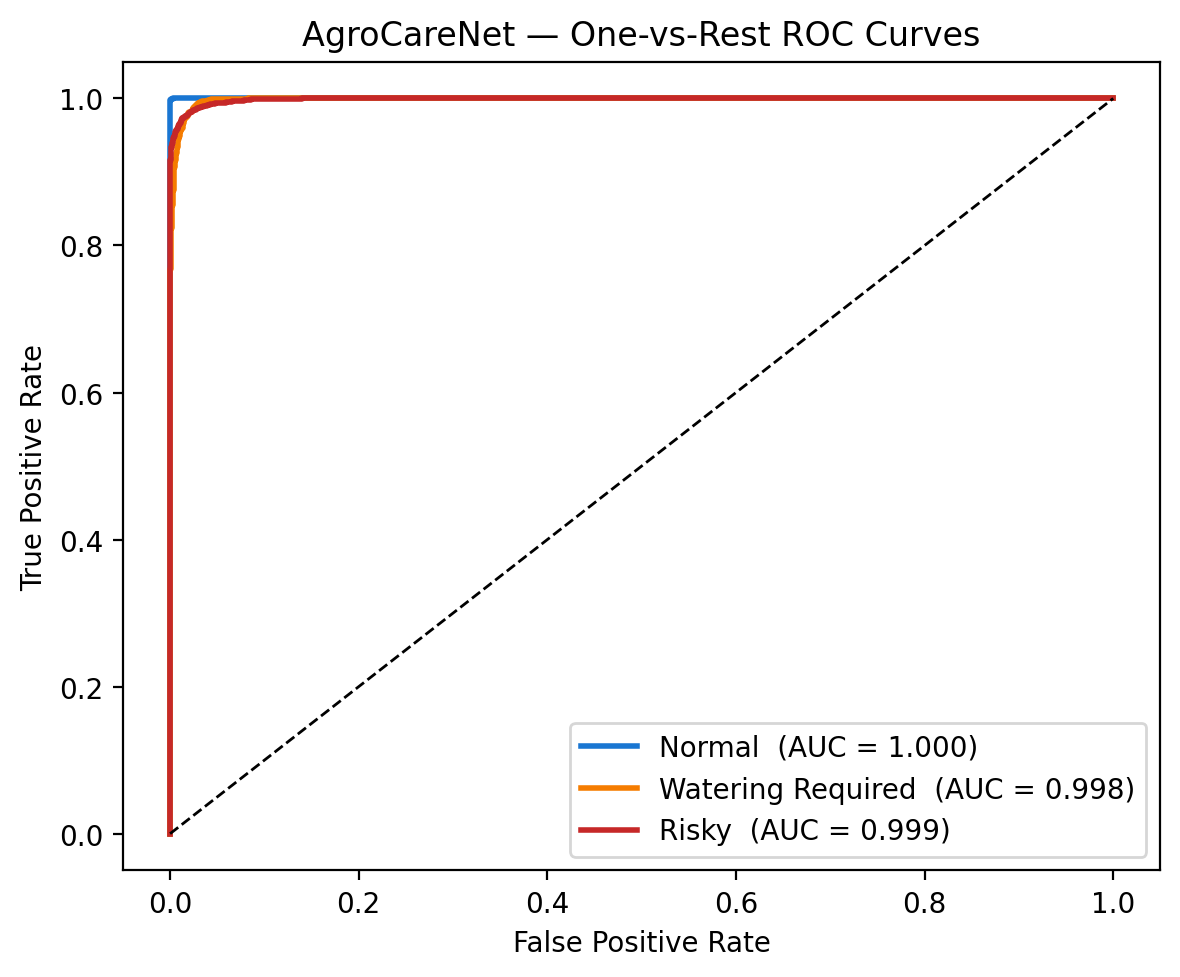

In [29]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from IPython.display import Image, display
from inference import load_model
from train import CLASS_NAMES

checkpoint_path = Path("checkpoints/best_model.pt")
report_dir = Path("plots/report")
report_dir.mkdir(parents=True, exist_ok=True)

if checkpoint_path.exists() and DATA_PATH.exists():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, norm_stats = load_model(str(checkpoint_path), device)
    data = np.load(DATA_PATH)
    X_raw, y = data["X"], data["y"]
    X_tensor = torch.tensor(X_raw, dtype=torch.float32, device=device)
    X_norm = (X_tensor - norm_stats["means"]) / norm_stats["stds"]
    with torch.no_grad():
        probs = torch.softmax(model(X_norm), dim=1).cpu().numpy()

    y_bin  = label_binarize(y, classes=[0, 1, 2])
    colors = ["#1976D2", "#F57C00", "#C62828"]

    fig, ax = plt.subplots(figsize=(6, 5))
    for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, color=color, lw=2, label=f"{name}  (AUC = {auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("AgroCareNet — One-vs-Rest ROC Curves")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(report_dir / "deep_roc.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=report_dir / "deep_roc.png"))
else:
    print("Checkpoint or dataset not found.")


## Per-Class F1 Comparison

Per-class F1 scores for the logistic regression baseline and AgroCareNet, plotted side by side. The gap is most pronounced on the Watering Required class, where temporal trends in soil moisture provide a signal that summary statistics cannot capture.

[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]


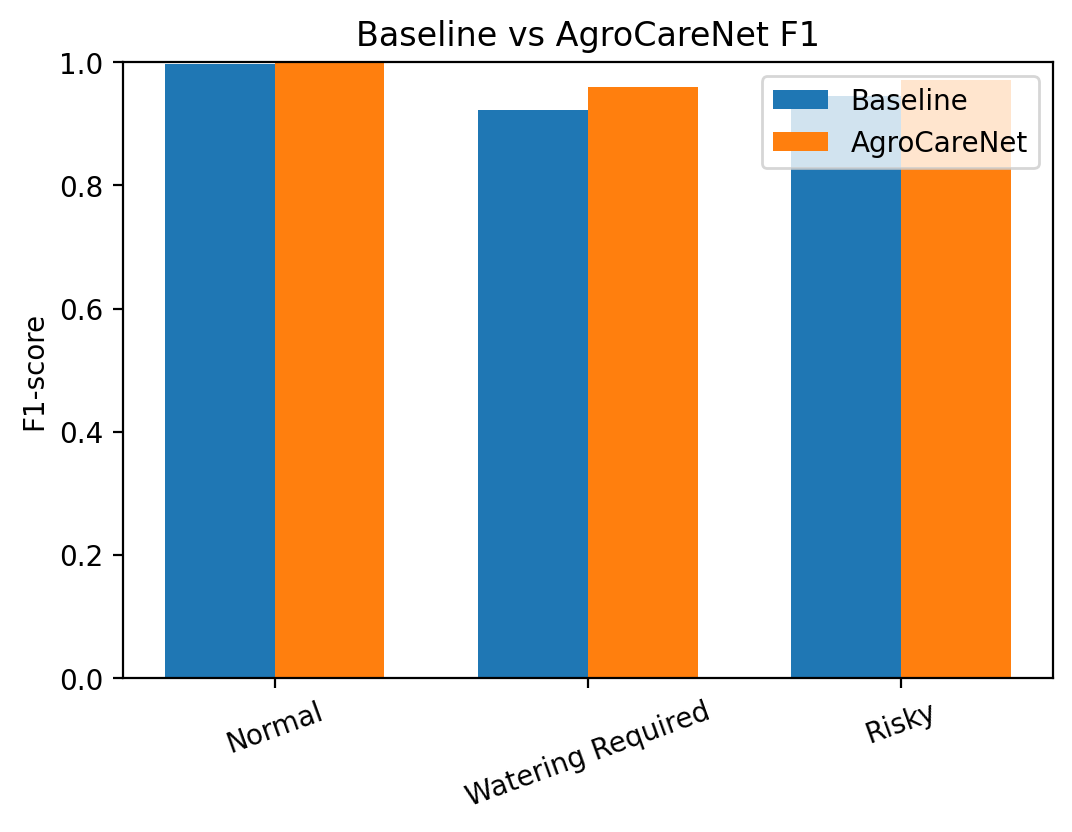

In [30]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from IPython.display import Image, display
from inference import load_model

checkpoint_path = Path("checkpoints/best_model.pt")
report_dir = Path("plots/report")
report_dir.mkdir(parents=True, exist_ok=True)

baseline_f1 = None
deep_f1 = None

if DATA_PATH.exists() and baseline_metrics is not None:
    baseline_f1 = [baseline_metrics.report[name]["f1-score"] for name in CLASS_NAMES]

if checkpoint_path.exists() and DATA_PATH.exists():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, norm_stats = load_model(str(checkpoint_path), device)
    data = np.load(DATA_PATH)
    X_raw, y = data["X"], data["y"]
    X_tensor = torch.tensor(X_raw, dtype=torch.float32, device=device)
    X_norm = (X_tensor - norm_stats["means"]) / norm_stats["stds"]
    with torch.no_grad():
        logits = model(X_norm)
        preds = torch.softmax(logits, dim=1).cpu().numpy()
    report = classification_report(y, preds.argmax(axis=1), target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    deep_f1 = [report[name]["f1-score"] for name in CLASS_NAMES]

if baseline_f1 and deep_f1:
    x = np.arange(len(CLASS_NAMES))
    width = 0.35
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, baseline_f1, width, label="Baseline")
    ax.bar(x + width/2, deep_f1, width, label="AgroCareNet")
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title("Baseline vs AgroCareNet F1")
    fig.savefig(report_dir / "f1_comparison.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=report_dir / "f1_comparison.png"))
else:
    print("Need both baseline and AgroCareNet results to plot comparison.")


## Confusion Matrix Comparison

Both confusion matrices rendered side by side. The logistic regression baseline relies on four handcrafted statistics per channel; AgroCareNet learns directly from the full 60-step waveform. The Watering Required class shows the largest accuracy gap between the two models, reflecting the value of temporal pattern learning for detecting early moisture decline.

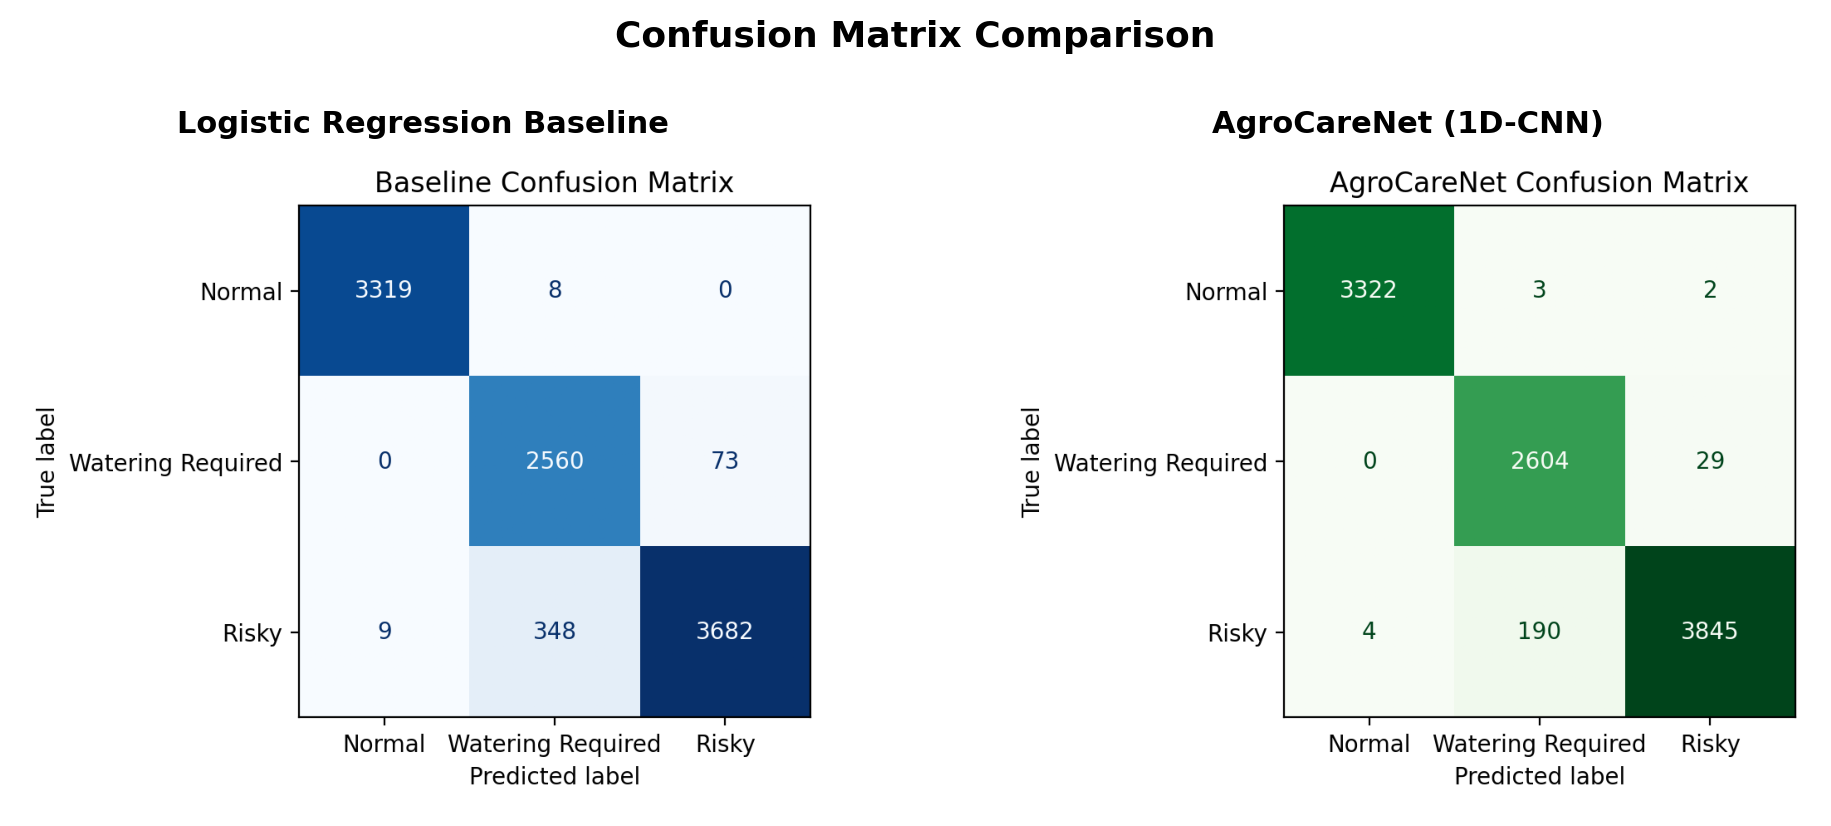

In [31]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

report_dir   = Path("plots/report")
baseline_img = report_dir / "baseline_confusion.png"
deep_img     = report_dir / "deep_confusion.png"

if baseline_img.exists() and deep_img.exists():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    titles = ["Logistic Regression Baseline", "AgroCareNet (1D-CNN)"]
    for ax, path, title in zip(axes, [baseline_img, deep_img], titles):
        ax.imshow(mpimg.imread(str(path)))
        ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
        ax.axis("off")
    fig.suptitle("Confusion Matrix Comparison", fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(report_dir / "confusion_comparison.png", dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=report_dir / "confusion_comparison.png"))
else:
    print("Generate both confusion matrices first (baseline and AgroCareNet evaluation cells).")


In [38]:
import importlib
import models.baseline as baseline_mod
baseline_mod = importlib.reload(baseline_mod)
from train import CLASS_NAMES, AgroCareDataset
import numpy as np

SCENARIOS = [
    {
        "label": "Healthy plant — optimal conditions",
        "description": "Soil moisture 70%, mild temperatures, moderate UV",
        "values": [70.0, 30.0, 32.0, 55.0, 3.0],
    },
    {
        "label": "Irrigation needed — moisture deficit detected",
        "description": "Soil moisture dropped to 20%, soil temperature rising",
        "values": [20.0, 33.0, 34.0, 50.0, 4.5],
    },
    {
        "label": "High-stress state — immediate intervention required",
        "description": "Critical moisture, extreme heat and UV, low humidity",
        "values": [9.0, 39.0, 42.0, 28.0, 8.5],
    },
]

SENSORS = ["Soil Moisture (%)", "Soil Temp (°C)", "Ambient Temp (°C)", "Humidity (%)", "UV Index"]

if DATA_PATH.exists() and baseline_metrics is not None:
    data = np.load(DATA_PATH)
    dataset = AgroCareDataset(data["X"], data["y"], normalize=True)
    for scenario in SCENARIOS:
        try:
            pred = baseline_mod.predict_snapshot(baseline_metrics.pipeline, scenario["values"], noise_std=0.5)
        except TypeError:
            pred = baseline_mod.predict_snapshot(
                baseline_metrics.pipeline,
                scenario["values"],
                dataset.channel_means.numpy(),
                dataset.channel_stds.numpy(),
            )
        probs = pred["probabilities"]
        print("" + "═" * 52)
        print(f"  {scenario['label']}")
        print(f"  {scenario['description']}")
        print("  " + "─" * 48)
        print("  {label:<22}  {val:>6}".format(label="Sensor", val="Value"))
        print("  " + "─" * 48)
        for name, val in zip(SENSORS, scenario["values"]):
            print(f"  {name:<22}  {val:>6.1f}")
        print("  " + "─" * 48)
        print(f"  Prediction : {pred['class_name']}")
        print("  " + "─" * 48)
        for cls in CLASS_NAMES:
            filled = int(probs[cls] * 24)
            bar = "█" * filled + "░" * (24 - filled)
            print(f"  {cls:<20}  {bar}  {probs[cls]:.4f}")
    print("" + "═" * 52)
else:
    print("Run the baseline training cell first.")


════════════════════════════════════════════════════
  Healthy plant — optimal conditions
  Soil moisture 70%, mild temperatures, moderate UV
  ────────────────────────────────────────────────
  Sensor                   Value
  ────────────────────────────────────────────────
  Soil Moisture (%)         70.0
  Soil Temp (°C)            30.0
  Ambient Temp (°C)         32.0
  Humidity (%)              55.0
  UV Index                   3.0
  ────────────────────────────────────────────────
  Prediction : Normal
  ────────────────────────────────────────────────
  Normal                ███████████████████████░  0.9995
  Watering Required     ░░░░░░░░░░░░░░░░░░░░░░░░  0.0005
  Risky                 ░░░░░░░░░░░░░░░░░░░░░░░░  0.0000
════════════════════════════════════════════════════
  Irrigation needed — moisture deficit detected
  Soil moisture dropped to 20%, soil temperature rising
  ────────────────────────────────────────────────
  Sensor                   Value
  ────────────────────

## Model Architecture

AgroCareNet is a 1D convolutional network with a dual-attention fusion head, designed to classify 60-step multivariate sensor windows into three plant health states.

The backbone applies three sequential Conv1d blocks that progressively expand feature channels from 5 to 128 while halving the temporal dimension through max-pooling (60 → 30 → 15 steps). The resulting feature map feeds two parallel attention mechanisms: a multi-head self-attention module that identifies which timesteps carry discriminative signal, and a squeeze-and-excitation block that recalibrates the relative importance of each feature channel. The two 128-dimensional attention outputs are concatenated and passed through a two-layer classifier head (256 → 64 → 3) with GELU activation and dropout regularization.

The architecture diagram and text summary below show the data flow and parameter counts for each stage.

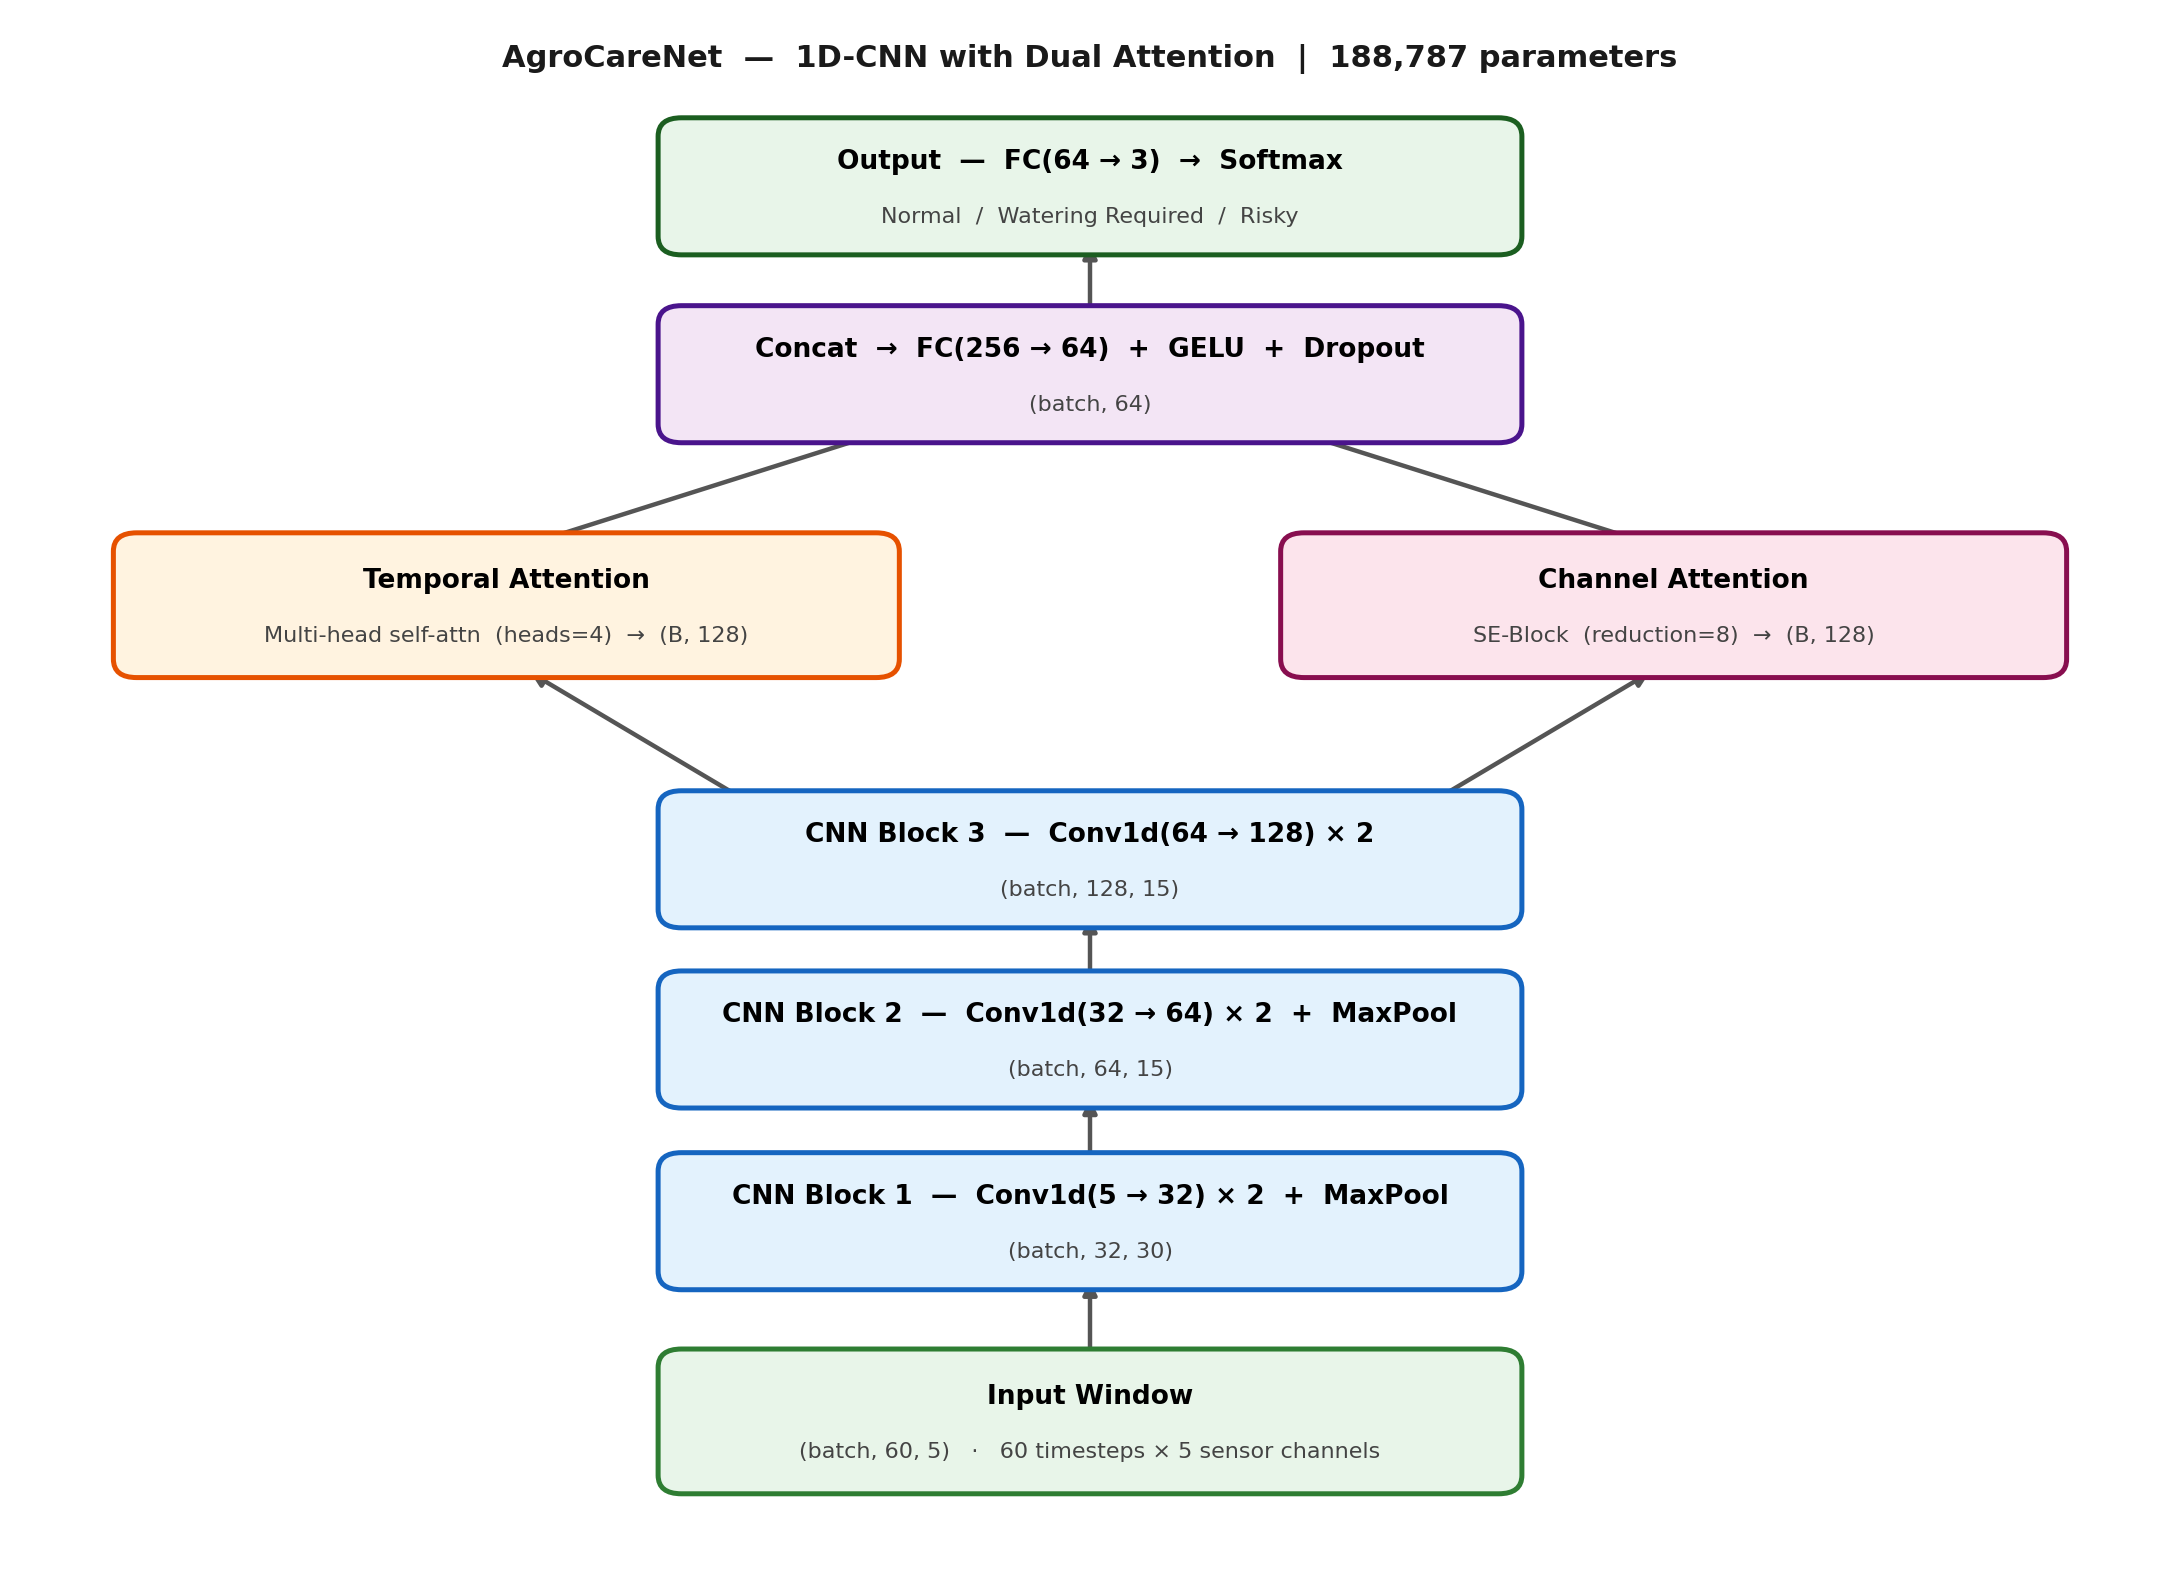

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import Image, display

report_dir = Path("plots/report")
report_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 11)
ax.set_ylim(0, 10)
ax.axis("off")

def block(ax, cx, cy, w, h, title, subtitle="", fc="#E3F2FD", ec="#1565C0"):
    rect = mpatches.FancyBboxPatch(
        (cx - w / 2, cy - h / 2), w, h,
        boxstyle="round,pad=0.12", facecolor=fc, edgecolor=ec, linewidth=1.8, zorder=3,
    )
    ax.add_patch(rect)
    yo = 0.16 if subtitle else 0
    ax.text(cx, cy + yo, title, ha="center", va="center",
            fontsize=9.5, fontweight="bold", zorder=4)
    if subtitle:
        ax.text(cx, cy - 0.2, subtitle, ha="center", va="center",
                fontsize=8, color="#444444", zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#555555", lw=1.6),
                zorder=2)

# ── Input ──────────────────────────────────────────────
block(ax, 5.5, 0.9, 4.2, 0.7,
      "Input Window",
      "(batch, 60, 5)   ·   60 timesteps × 5 sensor channels",
      fc="#E8F5E9", ec="#2E7D32")

# ── CNN Backbone ────────────────────────────────────────
arrow(ax, 5.5, 1.25, 5.5, 1.85)
block(ax, 5.5, 2.2, 4.2, 0.65,
      "CNN Block 1  —  Conv1d(5 → 32) × 2  +  MaxPool",
      "(batch, 32, 30)",
      fc="#E3F2FD", ec="#1565C0")

arrow(ax, 5.5, 2.53, 5.5, 3.03)
block(ax, 5.5, 3.38, 4.2, 0.65,
      "CNN Block 2  —  Conv1d(32 → 64) × 2  +  MaxPool",
      "(batch, 64, 15)",
      fc="#E3F2FD", ec="#1565C0")

arrow(ax, 5.5, 3.71, 5.5, 4.21)
block(ax, 5.5, 4.55, 4.2, 0.65,
      "CNN Block 3  —  Conv1d(64 → 128) × 2",
      "(batch, 128, 15)",
      fc="#E3F2FD", ec="#1565C0")

# ── Dual Attention ──────────────────────────────────────
# split arrow left and right from CNN Block 3
arrow(ax, 3.8, 4.88, 2.6, 5.78)
arrow(ax, 7.2, 4.88, 8.4, 5.78)

block(ax, 2.5, 6.2, 3.8, 0.7,
      "Temporal Attention",
      "Multi-head self-attn  (heads=4)  →  (B, 128)",
      fc="#FFF3E0", ec="#E65100")

block(ax, 8.5, 6.2, 3.8, 0.7,
      "Channel Attention",
      "SE-Block  (reduction=8)  →  (B, 128)",
      fc="#FCE4EC", ec="#880E4F")

# ── merge arrows ────────────────────────────────────────
arrow(ax, 2.5, 6.55, 4.5, 7.35)
arrow(ax, 8.5, 6.55, 6.5, 7.35)

# ── Fusion ──────────────────────────────────────────────
block(ax, 5.5, 7.7, 4.2, 0.65,
      "Concat  →  FC(256 → 64)  +  GELU  +  Dropout",
      "(batch, 64)",
      fc="#F3E5F5", ec="#4A148C")

arrow(ax, 5.5, 8.03, 5.5, 8.58)

# ── Output ──────────────────────────────────────────────
block(ax, 5.5, 8.92, 4.2, 0.65,
      "Output  —  FC(64 → 3)  →  Softmax",
      "Normal  /  Watering Required  /  Risky",
      fc="#E8F5E9", ec="#1B5E20")

# ── Title ───────────────────────────────────────────────
ax.text(5.5, 9.75,
        "AgroCareNet  —  1D-CNN with Dual Attention  |  188,787 parameters",
        ha="center", va="center", fontsize=11, fontweight="bold", color="#1A1A1A")

fig.tight_layout()
fig.savefig(report_dir / "model_arch.png", dpi=200, bbox_inches="tight")
plt.close(fig)
display(Image(filename=report_dir / "model_arch.png"))


In [22]:
import torch
from models.agrocare_net import AgroCareNet

model = AgroCareNet()
dummy = torch.randn(2, 60, 5)
logits = model(dummy)
print('Logits shape:', logits.shape)
print(model.summary())


Logits shape: torch.Size([2, 3])
  AgroCareNet — 1D-CNN + Dual Attention
  Input shape    : (B, 60, 5)
  Output classes : 3
  Feature dim    : 128
  Total params   : 188,787

  Backbone:
    Block 1: Conv1d(5→32) × 2 + Pool → (B, 32, 30)
    Block 2: Conv1d(32→64) × 2 + Pool → (B, 64, 15)
    Block 3: Conv1d(64→128) × 2       → (B, 128, 15)

  Attention:
    Temporal: MultiHeadAttention(dim=128, heads=4)
    Channel:  SE-Block(128, reduction=8)

  Classifier:
    Concat(128+128) → FC(256→64) → GELU → FC(64→3)


## Train the Model
`train.py` handles deterministic splits, class-weighted loss, ReduceLROnPlateau scheduling, checkpoints, and plots. Key CLI flags: `--dataset`, `--epochs`, `--batch-size`, `--lr`, `--checkpoint-every`.


In [ ]:
%%bash
python train.py \
  --dataset data/dev/agrocare_dataset.npz \
  --epochs 20 \
  --batch-size 64 \
  --checkpoint-every 5


## Inference Demo
`inference.py` loads checkpoints (which include normalization stats) and predicts from single sensor snapshots or CSV batches. The snippet below runs a quick single-snapshot prediction if `checkpoints/best_model.pt` exists.


## Scenario Sweep (Baseline & AgroCareNet)

Quick sanity check on multiple hand-crafted sensor snapshots using both models.

In [40]:
import importlib
import models.baseline as baseline_mod
baseline_mod = importlib.reload(baseline_mod)
from inference import predict_from_snapshot as predict_deep, load_model
from pathlib import Path
import torch
import numpy as np
import pandas as pd

scenarios = [
    {"name": "Healthy", "values": [70.0, 30.0, 32.0, 55.0, 3.0]},
    {"name": "Watering Needed", "values": [12.0, 35.0, 36.0, 30.0, 5.0]},
    {"name": "Risky", "values": [5.0, 45.0, 45.0, 20.0, 9.0]},
]

results = []
checkpoint_path = Path("checkpoints/best_model.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for scenario in scenarios:
    row = {"scenario": scenario["name"], **{f"sensor_{i}": v for i, v in enumerate(scenario["values"])}}
    if baseline_metrics is not None:
        try:
            b_pred = baseline_mod.predict_snapshot(
                baseline_metrics.pipeline,
                scenario["values"],
                noise_std=0.5,
            )
        except TypeError:
            from train import AgroCareDataset
            data = np.load(DATA_PATH)
            ds = AgroCareDataset(data["X"], data["y"], normalize=True)
            b_pred = baseline_mod.predict_snapshot(
                baseline_metrics.pipeline,
                scenario["values"],
                ds.channel_means.numpy(),
                ds.channel_stds.numpy(),
            )
        row["baseline_class"] = b_pred["class_name"]
        row["baseline_probs"] = b_pred["probabilities"]
    if checkpoint_path.exists():
        deep_model, deep_norm = load_model(str(checkpoint_path), device)
        d_pred = predict_deep(deep_model, deep_norm, scenario["values"], device)
        row["deep_class"] = d_pred["class_name"]
        row["deep_probs"] = d_pred["probabilities"]
    results.append(row)

df = pd.DataFrame(results)
display(df[["scenario", "baseline_class", "deep_class"]])
pd.set_option("display.max_colwidth", None)
display(df[["scenario", "baseline_probs", "deep_probs"]])


[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]
[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]
[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]


,scenario,baseline_class,deep_class
0,Healthy,Normal,Normal
1,Watering Needed,Risky,Watering Required
2,Risky,Risky,Risky


,scenario,baseline_probs,deep_probs
0,Healthy,"{'Normal': 0.9995000636562772, 'Watering Required': 0.0004999362694649262, 'Risky': 7.425789531416448e-11}","{'Normal': 1.0, 'Watering Required': 0.0, 'Risky': 0.0}"
1,Watering Needed,"{'Normal': 3.648265239626554e-06, 'Watering Required': 0.12926199020570753, 'Risky': 0.8707343615290528}","{'Normal': 0.0, 'Watering Required': 0.9372, 'Risky': 0.0628}"
2,Risky,"{'Normal': 2.404601859509563e-13, 'Watering Required': 7.833102365459989e-05, 'Risky': 0.999921668976105}","{'Normal': 0.0, 'Watering Required': 0.0, 'Risky': 1.0}"


In [19]:
from pathlib import Path
import torch
from inference import load_model, predict_from_snapshot

checkpoint_path = Path('checkpoints/best_model.pt')

if checkpoint_path.exists():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model, norm_stats = load_model(str(checkpoint_path), device)
    demo_values = [70.0, 30.0, 32.0, 55.0, 3.0]
    result = predict_from_snapshot(model, norm_stats, demo_values, device)
    print('Predicted class:', result['class_name'])
    print('Probabilities:', result['probabilities'])
else:
    print('Train the model first to create checkpoints/best_model.pt.')


[MODEL] Loading checkpoint from checkpoints/best_model.pt
         Epoch: 49, Best val_loss: 0.0685902510706293
         Parameters: 188,787
         Norm means: [32.33 32.22 34.21 46.02  5.32]
         Norm stds:  [27.86  6.78  7.59 15.72  3.32]
Predicted class: Normal
Probabilities: {'Normal': 1.0, 'Watering Required': 0.0, 'Risky': 0.0}
